In [2]:
#@title Default title text
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

#!ls 'drive/My Drive/local training'
import os
os.chdir('drive/My Drive/Doktora/TBC/Mescere/Ladin')

Mounted at /content/drive


In [3]:
!pip install laspy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.3/84.3 kB 8.8 MB/s eta 0:00:00


In [4]:
!pip install alphashape

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 543.2/543.2 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 704.8/704.8 kB 49.0 MB/s eta 0:00:00


In [5]:
!pip install pyvista

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 79.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 92.1/92.1 MB 23.4 MB/s eta 0:00:00


In [6]:
import laspy
import numpy as np
from scipy.spatial import ConvexHull
from scipy.spatial.distance import pdist
import matplotlib.pyplot as plt

import alphashape
import matplotlib.pyplot as plt
from shapely.geometry import Point, Polygon
from scipy.spatial import Delaunay
import pyvista as pv
import numpy as np
import math

In [7]:
# Nokta bulutu verisini yükleme
lidar_file = laspy.read("tree1079.las")

In [8]:
# Nokta bulutunu numpy array'e dönüştürme
points = np.vstack((lidar_file.x, lidar_file.y, lidar_file.z)).transpose()

In [9]:
# Maksimum ağaç yüksekliği
tree_height = points[:, 2].max()

print(f"Ağaç Yüksekliği (H): {tree_height:.2f} metre")

Ağaç Yüksekliği (H): 19.28 metre


In [10]:
# Gövde çapını (Diameter at Breast Height) bulma
dbh_height = 1.3
dbh_points = points[(points[:, 2] > dbh_height - 0.2) & (points[:, 2] < dbh_height + 0.2)]
dbh_2d = dbh_points[:, :2]
hull = ConvexHull(dbh_2d)
dbh_diameter = np.max(pdist(dbh_2d[hull.vertices]))

print(f"Ağaç gövde çapı (DBH): {dbh_diameter:.2f} metre")

Ağaç gövde çapı (DBH): 0.59 metre


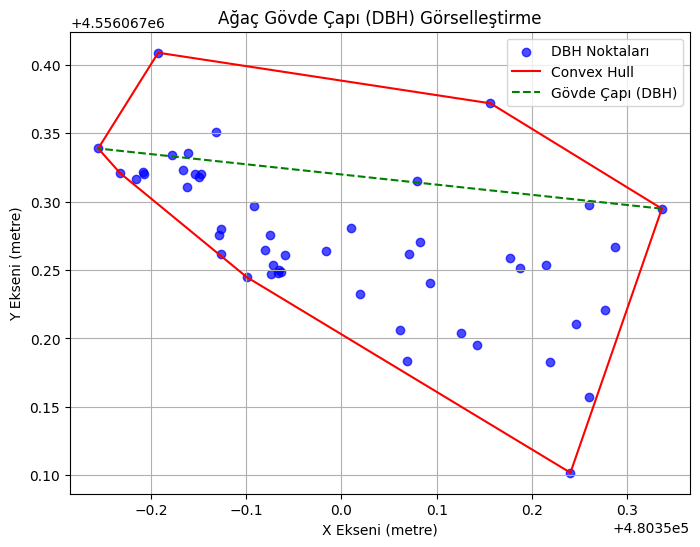

In [16]:
# Görselleştirme
plt.figure(figsize=(8, 6))

# DBH noktalarını çizme
plt.scatter(dbh_2d[:, 0], dbh_2d[:, 1], color="blue", label="DBH Noktaları", alpha=0.7)

# Convex Hull sınırlarını çizme
for simplex in hull.simplices:
    plt.plot(dbh_2d[simplex, 0], dbh_2d[simplex, 1], color="red", label="Convex Hull" if simplex[0] == hull.vertices[0] else "")

# Calculate pairwise distances between DBH points
from scipy.spatial.distance import pdist
distances = pdist(dbh_2d[hull.vertices])

# Maksimum çapı (DBH) gösterme
max_dist_idx = np.argmax(distances) # Get the index of the maximum distance

# Get the indices of the points in dbh_2d using triangulation
# instead of unravel_index
point1_idx, point2_idx = np.triu_indices(len(hull.vertices), k=1)[0][max_dist_idx], np.triu_indices(len(hull.vertices), k=1)[1][max_dist_idx]

point1, point2 = dbh_2d[hull.vertices[point1_idx]], dbh_2d[hull.vertices[point2_idx]] # Get the actual points
plt.plot([point1[0], point2[0]], [point1[1], point2[1]], color="green", linestyle="--", label="Gövde Çapı (DBH)")

# Eksen ayarları ve başlık
plt.xlabel("X Ekseni (metre)")
plt.ylabel("Y Ekseni (metre)")
plt.title("Ağaç Gövde Çapı (DBH) Görselleştirme")
plt.legend()
plt.grid()
plt.show()

In [11]:
# Tepe çapını (Crown Diameter) bulma
cd_2d = points[:, :2]
hull = ConvexHull(cd_2d)
cd_diameter = np.max(pdist(cd_2d[hull.vertices]))

print(f"Ağaç tepe çapı (CD): {cd_diameter:.2f} metre")

Ağaç tepe çapı (CD): 7.42 metre


In [12]:
# Taç Alanını (Canopy Area) Bulma
canopy_2d = points[:, :2]
convex_hull = ConvexHull(canopy_2d)
canopy_area = convex_hull.area  # Convex hull'un 2D yüzey alanı

print(f"Ağaç taç alanı: {canopy_area:.2f} metrekare")

Ağaç taç alanı: 21.96 metrekare


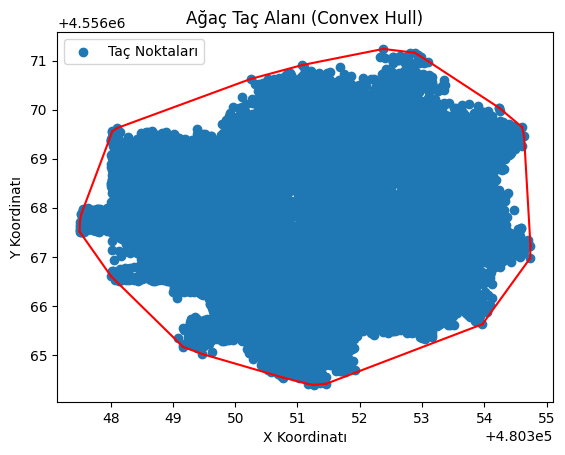

In [13]:
# Çizim
plt.scatter(canopy_2d[:, 0], canopy_2d[:, 1], label="Taç Noktaları")
for simplex in hull.simplices:
    plt.plot(canopy_2d[simplex, 0], canopy_2d[simplex, 1], 'r-')

plt.title("Ağaç Taç Alanı (Convex Hull)")
plt.xlabel("X Koordinatı")
plt.ylabel("Y Koordinatı")
plt.legend()
plt.show()

Sadece sınırdaki en uzak noktaların koordinatları:
[[4.80348466e+05 4.55606725e+06 4.13500000e+00]
 [4.80349362e+05 4.55606725e+06 1.62790000e+01]
 [4.80349910e+05 4.55606725e+06 1.64060000e+01]
 ...
 [4.80349596e+05 4.55606725e+06 4.88300000e+00]
 [4.80349393e+05 4.55606725e+06 5.08300000e+00]
 [4.80348858e+05 4.55606725e+06 1.62190000e+01]]


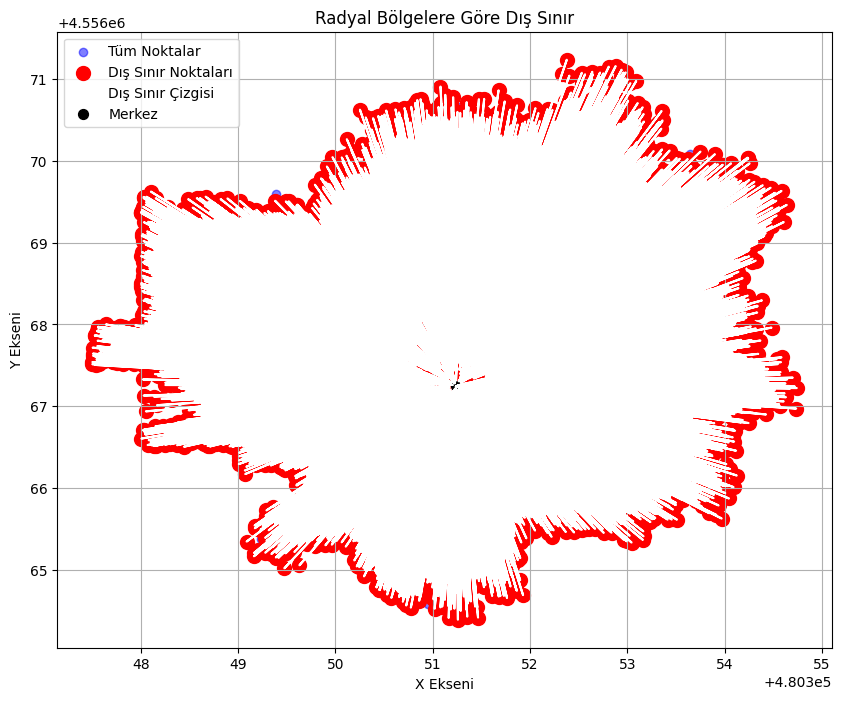

Dış sınır noktalarının koordinatları:
[[4.80348466e+05 4.55606725e+06 4.13500000e+00]
 [4.80349362e+05 4.55606725e+06 1.62790000e+01]
 [4.80349910e+05 4.55606725e+06 1.64060000e+01]
 ...
 [4.80349596e+05 4.55606725e+06 4.88300000e+00]
 [4.80349393e+05 4.55606725e+06 5.08300000e+00]
 [4.80348858e+05 4.55606725e+06 1.62190000e+01]]


In [98]:
points1 = points[:, :2]

# 1. Merkezin hesaplanması
center = np.mean(points, axis=0)

# 2. Noktaların merkezden radyal açılarının hesaplanması
angles = np.arctan2(points[:, 1] - center[1], points[:, 0] - center[0])  # Açılar (radyan)

# 3. Noktaları açılarına göre sıralama
sorted_indices = np.argsort(angles)  # Açıya göre sıralı indeksler
sorted_points = points[sorted_indices]
sorted_angles = angles[sorted_indices]

# 4. Her radyal yöndeki en uzak noktaları seçme
boundary_points = []
current_angle = None
max_distance = -np.inf

for idx, angle in zip(sorted_indices, sorted_angles):
    point = points[idx]
    distance = np.linalg.norm(point - center)  # Merkezden mesafe

    if current_angle is None or not np.isclose(angle, current_angle, atol=1e-8):
        # Yeni bir radyal bölgeye geçtiysek önceki en uzak noktayı ekle
        if current_angle is not None:
            boundary_points.append(farthest_point)
        # Sıfırla
        current_angle = angle
        max_distance = distance
        farthest_point = point
    elif distance > max_distance:
        # Aynı radyal yönde daha uzak bir nokta bulunursa güncelle
        max_distance = distance
        farthest_point = point

# Son radyal bölge için de en uzak noktayı ekle
boundary_points.append(farthest_point)

# 5. Boundary noktalarını numpy array'e dönüştürme
boundary_points = np.array(boundary_points)

# 6. Sonuçların yazdırılması
print("Sadece sınırdaki en uzak noktaların koordinatları:")
print(boundary_points)

# 6. Sonuçların görselleştirilmesi
plt.figure(figsize=(10, 8))
plt.scatter(points1[:, 0], points1[:, 1], color="blue", alpha=0.5, label="Tüm Noktalar")
plt.scatter(boundary_points[:, 0], boundary_points[:, 1], color="red", label="Dış Sınır Noktaları", s=100)
plt.plot(np.append(boundary_points[:, 0], boundary_points[0, 0]),
         np.append(boundary_points[:, 1], boundary_points[0, 1]),
         color="white", label="Dış Sınır Çizgisi")
plt.scatter(center[0], center[1], color="black", label="Merkez", s=50)
plt.title("Radyal Bölgelere Göre Dış Sınır")
plt.xlabel("X Ekseni")
plt.ylabel("Y Ekseni")
plt.legend()
plt.grid()
plt.show()

# Boundary noktalarının koordinatlarını yazdırma
print("Dış sınır noktalarının koordinatları:")
print(boundary_points)

In [99]:
# Calculate the area using Shapely
polygon = Polygon(boundary_points)
area = polygon.area

print(f"The area of the polygon is: {area}")

The area of the polygon is: 11.1536620238723


In [92]:
print(boundary_points)

[[ 480348.46649097 4556067.25186267]
 [ 480348.73749097 4556067.25186267]
 [ 480348.95949097 4556067.25186267]
 ...
 [ 480349.39349097 4556067.25286267]
 [ 480348.85849097 4556067.25286267]
 [ 480348.81149097 4556067.25286267]]


In [100]:
len(boundary_points)

31289

In [14]:
# Taç hacmini (Caonpy Volume) bulma
hull = ConvexHull(points)
canopy_volume = hull.volume

print(f"Ağaç taç hacmi: {canopy_volume:.2f} metreküp")

Ağaç taç hacmi: 411.11 metreküp


In [58]:
# Alpha Shape (Concave Hull)
alpha = 1  # Girinti düzeyi
points_2d = points[:, :2]
concave_hull = alphashape.alphashape(points_2d, alpha)
canopy_area = concave_hull.area  # Concav hull'un 2D yüzey alanı

print(f"Ağaç taç alanı: {canopy_area:.2f} metrekare")

Ağaç taç alanı: 34.45 metrekare


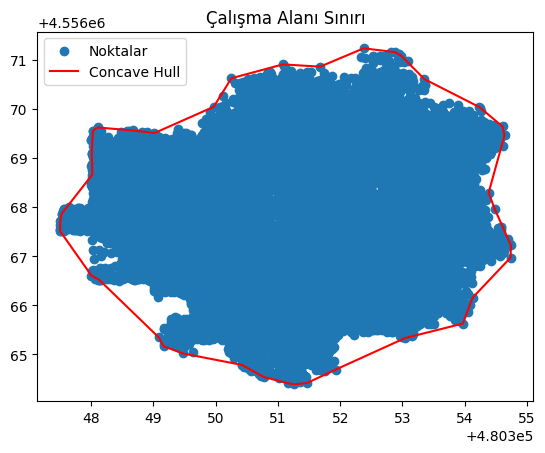

In [59]:
# Çizim
plt.scatter(points[:, 0], points[:, 1], label="Noktalar")
plt.plot(*concave_hull.exterior.xy, color='red', label="Concave Hull")
plt.title("Çalışma Alanı Sınırı")
plt.legend()
plt.show()

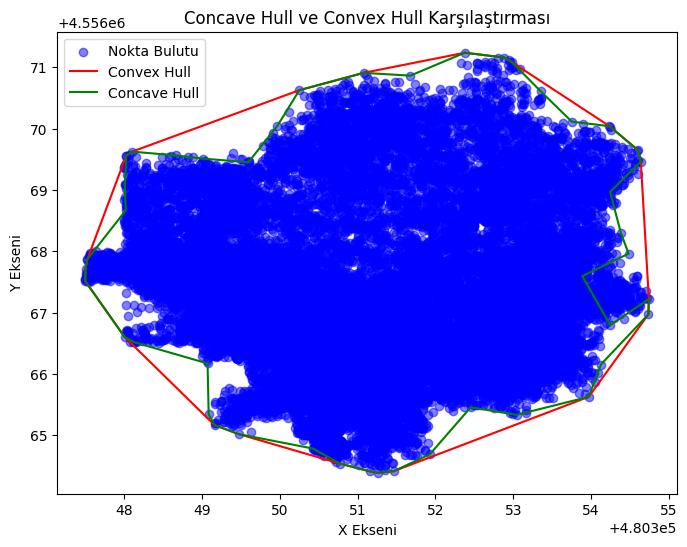

In [47]:
# 3. Görselleştirme (Concave ve Convex Hull)
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(points[:, 0], points[:, 1], color="blue", label="Nokta Bulutu", alpha=0.5)

# Convex Hull çizimi
for simplex in convex_hull.simplices:
    ax.plot(points[simplex, 0], points[simplex, 1], color="red", label="Convex Hull" if simplex[0] == convex_hull.vertices[0] else "")

# Concave Hull çizimi
x, y = concave_hull.exterior.xy
ax.plot(x, y, color="green", label="Concave Hull")

plt.legend()
plt.title("Concave Hull ve Convex Hull Karşılaştırması")
plt.xlabel("X Ekseni")
plt.ylabel("Y Ekseni")
plt.show()

In [48]:
# Concave Hull üzerinde yer alan noktaları bulma
hull_2d_coords = np.array(list(concave_hull.exterior.coords))

# Hull'un 3D noktalarını bulma
hull_3d_coords = []

for coord in hull_2d_coords:
    x, y = coord
    # Orijinal nokta bulutundaki X, Y koordinatları ile eşleştirerek Z değerini bul
    for px, py, pz in points:
        if np.isclose(x, px, atol=1e-5) and np.isclose(y, py, atol=1e-5):
            hull_3d_coords.append([px, py, pz])
            break

# Hull'a ait 3D noktaları numpy array'e dönüştür
hull_3d_coords = np.array(hull_3d_coords)

In [49]:
hull_3d_coords.shape[0]


47

In [50]:
# 1. Tacın yüksekliği
z_min = np.min(hull_3d_coords[:, 2])  # En düşük Z koordinatı
z_max = np.max(points[:, 2])  # En yüksek Z koordinatı
canopy_height = z_max - z_min

In [51]:
z_min, z_max

(10.881, 19.28)

In [29]:
# 2. Tacın taban çapı (X ve Y koordinatlarının maksimum yayılımı)
x_min, x_max = np.min(points[:, 0]), np.max(points[:, 0])
y_min, y_max = np.min(points[:, 1]), np.max(points[:, 1])
canopy_diameter = max(x_max - x_min, y_max - y_min)
canopy_radius = canopy_diameter / 2


In [30]:
# 3. Elipsoid yarıçapları
a = (x_max - x_min) / 2  # X yönünde yarıçap
b = (y_max - y_min) / 2  # Y yönünde yarıçap
c = canopy_height / 2    # Z yönünde yarıçap

In [31]:
# Konik model ile hacim hesaplama
cone_volume = (1 / 3) * math.pi * (canopy_radius**2) * canopy_height

In [32]:
# Elipsoid model ile hacim hesaplama
ellipsoid_volume = (4 / 3) * math.pi * a * b * c

In [33]:
# Sonuçları yazdırma
print(f"Tacın yüksekliği: {canopy_height:.2f} metre")
print(f"Tacın taban çapı: {canopy_diameter:.2f} metre")
print(f"Konik model ile hacim: {cone_volume:.2f} metreküp")
print(f"Elipsoid model ile hacim: {ellipsoid_volume:.2f} metreküp")

Tacın yüksekliği: 18.89 metre
Tacın taban çapı: 7.24 metre
Konik model ile hacim: 259.37 metreküp
Elipsoid model ile hacim: 490.72 metreküp


In [34]:
# Gövde Hacmi
trunk_height = tree_height - canopy_height
print(f"Ağaç gövde yüksekliği: {trunk_height:.2f} metre")

dbh_diameter = 0.40
radius = dbh_diameter / 2

trunk_volume = math.pi * (radius**2) * trunk_height
print(f"Silindirik model ile gövde hacmi: {trunk_volume:.2f} metreküp")

Ağaç gövde yüksekliği: 0.39 metre
Silindirik model ile gövde hacmi: 0.05 metreküp
